# Ensnarlment in physical networks
This is to test the ensnarlment between small synthetic lattices

Prerequisite:
- Package "Plotly" for 3D plots
- Package "kaleido" for saving 3D plots

## Imports

All analysis & visualization routines now live in the **`gemini_ensnarl`** package (see `gemini_ensnarl/`). Install it from the repository.

In [1]:
import numpy as np
import networkx as nx
import pandas as pd
from itertools import combinations

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import colormaps

import plotly
import plotly.graph_objects as go
import plotly.io as pio

from gemini_ensnarl import (
    Gauss_linking_integral,
    build_sibigraph,
    critical_flip_angles,
    candidate_mid_angles,
    sign_patterns_from_angles,
    generate_periodic_lattices,
    generate_ladder_lattices,
)
from gemini_ensnarl.viz_lattice import *


## Main - Example
This contains the 3 examples in Figure 1

### EG 1

In [2]:
# Circuit with squares + circuit with trees
# import random
lab_G = 'EG-1'

# Step 1: Create 3D grid graph G1
G1 = nx.grid_2d_graph(4, 2)

# Place nodes at z=0
for (i, j) in G1.nodes():
    G1.nodes[(i, j)]['pos'] = (i, j, 0)

# numeric the labels
labs1 = list(G1.nodes())
lab_num = list(range(len(labs1)))
G1 = nx.relabel_nodes(G1, dict(zip(G1.nodes(), lab_num)))

# Step 2: Create a small tree
pos = {0: (1,0,0.5), 2: (0,0,0.5), 3: (0,1,1),
      1: (2,1,-0.5), 4: (3,1,-0.5), 5: (3,0,-1),
      6: (1.5, 1.5, 0)}
edgelist = [(0,1), (0,2), (0,3), (1,4), (1,5),
            (0,6), (1,6)]

G2 = nx.Graph()
G2.add_nodes_from(pos.keys())
G2.add_edges_from(edgelist)
nx.set_node_attributes(G2, pos, name='pos')

graph_sets = [G1, G2]

In [3]:
# visualization
pos1 = extract_positions(graph_sets[0])
pos2 = extract_positions(graph_sets[1])

# ---- Create traces ----
trace_edges_G1 = edge_trace_3d(graph_sets[0], pos1, '#8a8a8a', 10)
trace_nodes_G1 = node_trace_3d(graph_sets[0], pos1, '#3f3f40', 8)

trace_edges_G2 = edge_trace_3d(graph_sets[1], pos2, '#2159d1', 10)
trace_nodes_G2 = node_trace_3d(graph_sets[1], pos2, '#3f3f40', 8)

# ---- Combine and plot ----
fig = go.Figure(data=[
    trace_edges_G1, trace_nodes_G1,
    trace_edges_G2, trace_nodes_G2
])

fig.update_layout(
    # title="3D Graph Visualization: G1_3D and G3",
    scene=dict(
        xaxis=dict(title='x'),
        yaxis=dict(title='y'),
        zaxis=dict(title='z'),
    ),
    showlegend=False,
    margin=dict(l=0, r=0, b=0, t=0),
    height=700
)
# fig.update_layout(scene_camera=camera)

fig.show()

In [4]:
camera = dict(
    eye=dict(x=-0.5, y=1.8, z=.8),
    center=dict(x=0, y=0, z=0),
    up=dict(x=0, y=0, z=.1)
) # this is for EG-1

fig.update_layout(scene_camera=camera)
fig.show()

In [5]:
figsize_g=(700, 500)
pio.write_image(fig, "{}-G.png".format(lab_G), width=figsize_g[0], height=figsize_g[1], scale=2) #, scale=2

In [6]:
plot_networkx_12label(G1, G2, pos1, pos2, camera=camera, lab_name=lab_G+'-G', figsize=figsize_g)

In [7]:
# GLI between edges directly
edges1 = list(graph_sets[0].edges())
edges2 = list(graph_sets[1].edges())

Lam_gli = np.zeros((len(edges1), len(edges2)))
for i in range(Lam_gli.shape[0]):
    e1 = edges1[i]
    e1_pos = [np.array(graph_sets[0].nodes[e1[0]]['pos']), np.array(graph_sets[0].nodes[e1[1]]['pos'])]
    for j in range(Lam_gli.shape[1]):
        e2 = edges2[j]
        # record the position
        e2_pos = [np.array(graph_sets[1].nodes[e2[0]]['pos']), np.array(graph_sets[1].nodes[e2[1]]['pos'])]
        # direct computation of Gauss linking integral
        gli_ij = Gauss_linking_integral(e1_pos, e2_pos)
        Lam_gli[i, j] = gli_ij

max abs value in Lam_gli: 0.3649072047774011


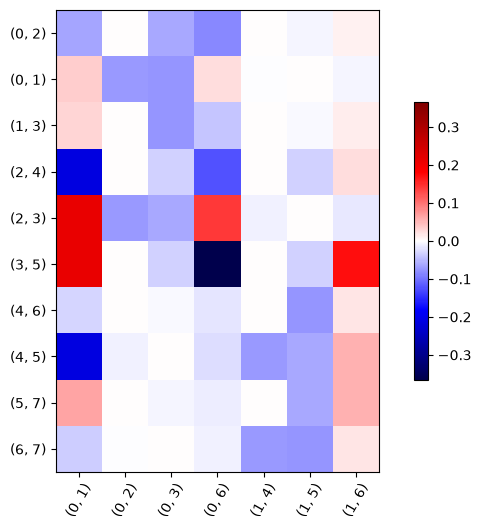

In [8]:
# Visualization
val_max = np.abs(Lam_gli).max()
print("max abs value in Lam_gli:", val_max)

plt.figure(figsize=(9, 6))
plt.imshow(Lam_gli, cmap='seismic', vmax=val_max, vmin=-val_max) #, aspect='auto'
# Set tick positions (match number of labels)
plt.xticks(ticks=np.arange(len(edges2)), labels=edges2, rotation=60)
plt.yticks(ticks=np.arange(len(edges1)), labels=edges1)

# Optional: show grid or colorbar
plt.grid(False)
plt.colorbar(shrink=0.6)
# plt.savefig("lad-Lam_gli.png", dpi=300, bbox_inches='tight')
plt.show()

#### Signed nature

In [9]:
labels_p1 = ['({},{})'.format(e[0], e[1]) for e in edges1]
labels_p2 = ['({},{})'.format(e[0]+G1.number_of_nodes(), e[1]+G1.number_of_nodes()) for e in edges2]

Gb = build_sibigraph(Lam_gli, labels_p1, labels_p2)

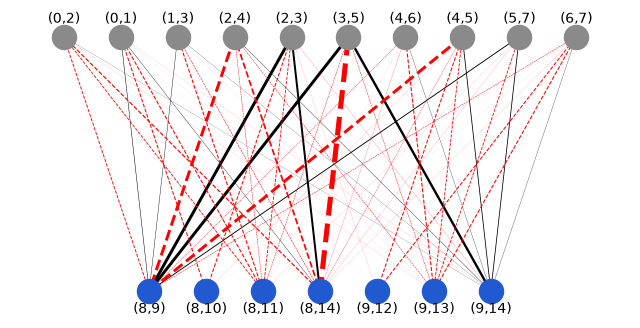

In [10]:
figsize = (8, 4)
draw_sibigraph(Gb, figname=lab_G, figsize=figsize, lab_diff=0.07)

In [11]:
# check the balance
W = np.block([[np.zeros((Lam_gli.shape[0], Lam_gli.shape[0])), Lam_gli], [Lam_gli.T, np.zeros((Lam_gli.shape[1], Lam_gli.shape[1]))]])

deg = np.sum(abs(W), axis=1)
# D_inv = np.diag(1./deg)
# P = D_inv.dot(W)
# eigvals = np.linalg.eigvals(P)

# symmetric version
D2_inv = np.diag(1./np.sqrt(deg))
P_sym = D2_inv.dot(W).dot(D2_inv)
eigvals = np.linalg.eigvals(P_sym)
print("Max eigenval of P:", np.max(eigvals))
# print("eigenvalues of P:", eigvals)

Max eigenval of P: 0.8037362261915815


Min eigenvalues of L: 0.05921845435688989
Min eigenvalue(s) of L: [0.05921845]


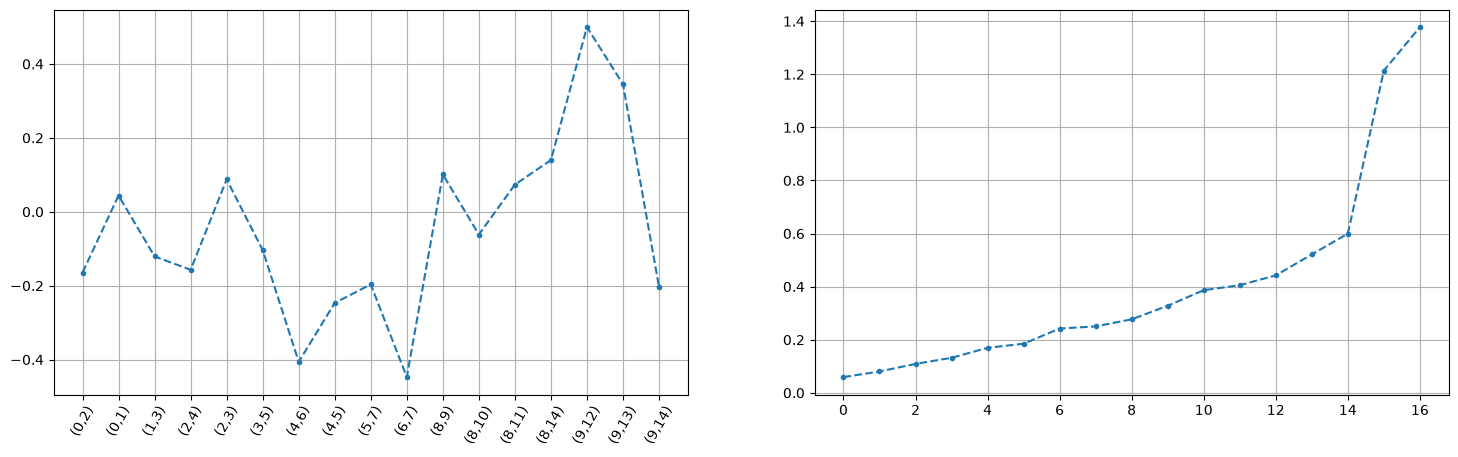

In [12]:
# check the eigenvectors
W = np.block([[np.zeros((Lam_gli.shape[0], Lam_gli.shape[0])), Lam_gli], [Lam_gli.T, np.zeros((Lam_gli.shape[1], Lam_gli.shape[1]))]])

deg = np.sum(abs(W), axis=1)
D = np.diag(deg)

L = D - W
eigvals, eigvecs = np.linalg.eigh(L)
print("Min eigenvalues of L:", min(eigvals))

# indices of the smallest value
tol = 1e-4
eval_min = min(eigvals)
idx = [i for i, val in enumerate(eigvals) if abs(val-eval_min) < tol]
print("Min eigenvalue(s) of L:", eigvals[idx])

plt.figure(figsize=(18, 5))
plt.subplot(121)
# choose the eigenvector(s)
for i in idx:
    plt.plot(eigvecs[:, i], marker='.', linestyle='dashed')
# xticks = edges1.copy()
# xticks.extend(edges2)
xticks = ['({},{})'.format(e[0], e[1]) for e in edges1]
xticks.extend(['({},{})'.format(e[0]+G1.number_of_nodes(), e[1]+G1.number_of_nodes()) for e in edges2])
plt.xticks(ticks=np.arange(len(xticks)), labels=xticks, rotation=60)
plt.grid(True)

plt.subplot(122)
plt.plot(eigvals, marker='.', linestyle='dashed')
plt.grid(True)
plt.show()

Min eigenvalues of L sym: 0.1962637738084203
Min eigenvalue(s) of L sym: [0.19626377]


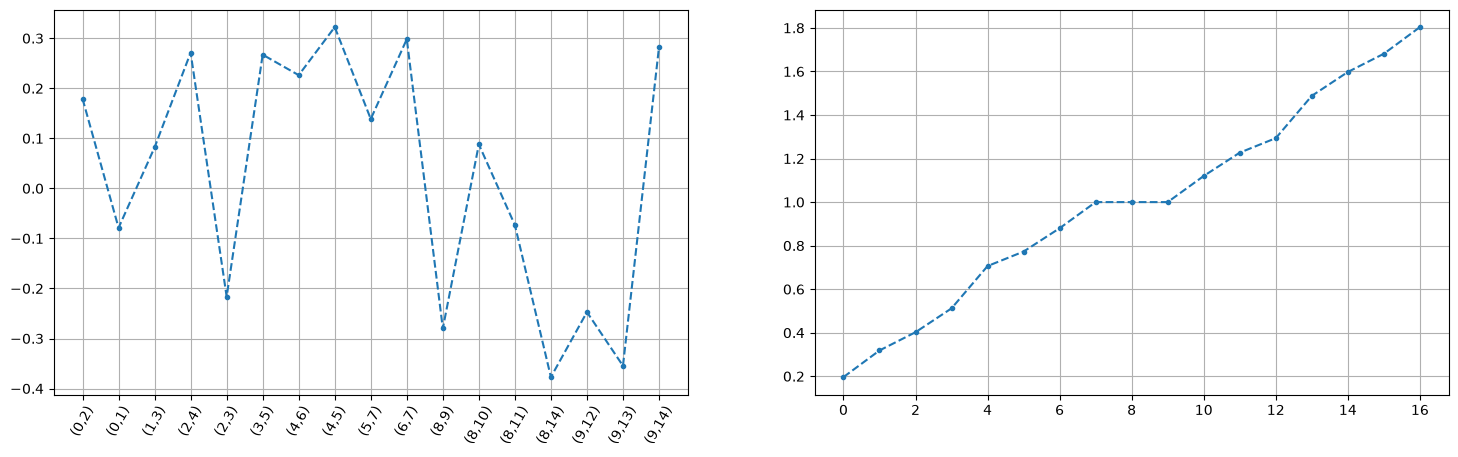

In [13]:
# check the eigenvectors - normalized Laplacian
W = np.block([[np.zeros((Lam_gli.shape[0], Lam_gli.shape[0])), Lam_gli], [Lam_gli.T, np.zeros((Lam_gli.shape[1], Lam_gli.shape[1]))]])

deg = np.sum(abs(W), axis=1)
D2_inv = np.diag(1./np.sqrt(deg))
L_sym = np.eye(W.shape[0]) - D2_inv.dot(W).dot(D2_inv)

eigvals, eigvecs = np.linalg.eigh(L_sym)
print("Min eigenvalues of L sym:", min(eigvals))

# indices of the smallest value
tol = 1e-4
eval_min = min(eigvals)
idx = [i for i, val in enumerate(eigvals) if abs(val-eval_min) < tol]
print("Min eigenvalue(s) of L sym:", eigvals[idx])

plt.figure(figsize=(18, 5))
plt.subplot(121)
# choose the eigenvector(s)
for i in idx:
    plt.plot(eigvecs[:, i], marker='.', linestyle='dashed')
# xticks = edges1.copy()
# xticks.extend(edges2)
xticks = ['({},{})'.format(e[0], e[1]) for e in edges1]
xticks.extend(['({},{})'.format(e[0]+G1.number_of_nodes(), e[1]+G1.number_of_nodes()) for e in edges2])
plt.xticks(ticks=np.arange(len(xticks)), labels=xticks, rotation=60)
plt.grid(True)

plt.subplot(122)
plt.plot(eigvals, marker='.', linestyle='dashed')
plt.grid(True)
plt.show()

Since all the values are clear from zero, we can use the vanilla format of the bi-clustering: separating the nodes into two clusters according to the sign of their corresponding elements in the eigenvector.

In [14]:
### Bi-Clustering ###
tol = 1e-4
nodec = []
idx_0s = []

for i,val in enumerate(eigvecs[:, idx[0]]):
    if val > tol:
        nodec.append(2)
    elif val < -tol:
        nodec.append(0)
    else:
        idx_0s.append(i)
        nodec.append(1)

if len(idx_0s) == 0:
    print("clear cut!")
    nodec = [1 if nodec[i] > 0 else 0 for i in range(len(nodec))]
else:
    print("# zeros in the eigenvector:", len(idx_0s))

clear cut!


In [15]:
# record the clustering result
s = np.array([1. if nodec[i] > 0 else -1. for i in range(len(nodec))]) # Default: all zeros in the same group as negatives
best_cost = s.T.dot(L).dot(s)
best_partition = [s]
size = len(idx_0s)
idx_0s = np.array(idx_0s)

print("Best cost:", best_cost)
print("# Best partition:", len(best_partition))

Best cost: 1.8840968556201036
# Best partition: 1


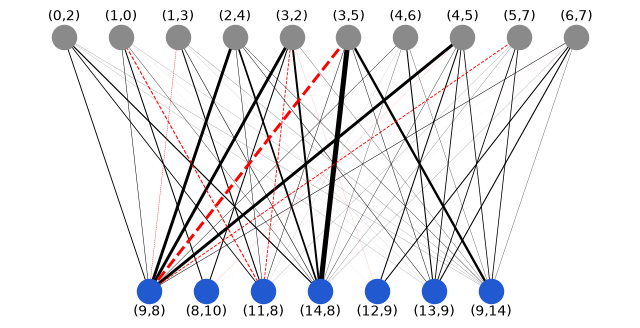

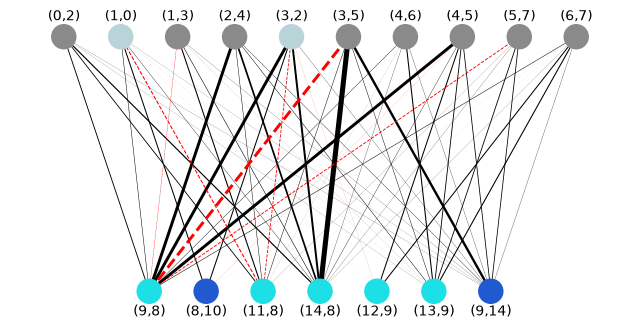

In [16]:
# Let's see the clustering result
lab_p = ''

idx_c = 0
for s in best_partition:

    nodec = [1 if s[i] > 0 else 0 for i in range(len(s))]
    # Partition
    # draw_sibigraph_nodec(Gb, nodec, cmap_name='coolwarm', figname=lab_G+lab_p+'-exact{}'.format(idx_c), figsize=figsize)
    # Switching
    # update the labels
    node_c = [nodec][0]

    # s = [1 if node_c[i] == 1 else -1 for i in range(len(node_c))]
    S = np.diag(s)
    W_s = S.dot(W.dot(S))
    B_s = W_s[:len(edges1), :][:, -len(edges2):]

    labels_p1s = []
    labels_p2s = []
    for i in range(len(edges1)):
        if node_c[i] == 1:
            labels_p1s.append(labels_p1[i])
        else:
            e = edges1[i]
            labels_p1s.append('({},{})'.format(e[1], e[0]))
    for j in range(len(edges2)):
        if node_c[j+len(edges1)] == 1:
            labels_p2s.append(labels_p2[j])
        else:
            e = edges2[j]
            labels_p2s.append('({},{})'.format(e[1]+G1.number_of_nodes(), e[0]+G1.number_of_nodes()))

    Gb_s = build_sibigraph(B_s, labels_p1s, labels_p2s)
    draw_sibigraph(Gb_s, figname=lab_G+'-switch'+lab_p+'-s{}'.format(idx_c), figsize=figsize)
    draw_sibigraph_node2c(Gb_s, node_c, figname=lab_G+'-switch'+lab_p+'-s{}'.format(idx_c), figsize=figsize)

    idx_c += 1

##### Check-ups

In [17]:
# check the exact solution -- only if small!!!
tol = 1e-4

gbest_cost = float(best_cost)
gbest_partition = []

size = L.shape[0]
s = np.ones(size)
for num in range(1, int((size+1.)/2. + 1)):
    # for every combination of the "num" number of nodes
    for idx_c in combinations(list(range(size)), num):
        s_now = s.copy()
        s_now[list(idx_c)] = -1
        cost = s_now.T.dot(L).dot(s_now)
        if cost < gbest_cost-tol:
            gbest_cost = cost
            gbest_partition = [s_now]
        elif abs(cost-gbest_cost) < tol:
            gbest_partition.append(s_now)

print("Best cost:", gbest_cost)
print("Best partition:", gbest_partition)

Best cost: 1.8840968556201036
Best partition: [array([ 1., -1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1., -1.,  1., -1.,
       -1., -1., -1.,  1.])]


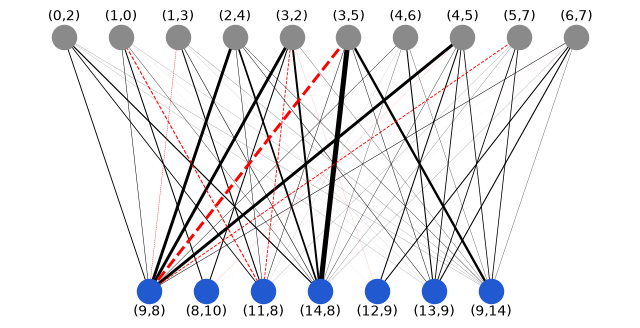

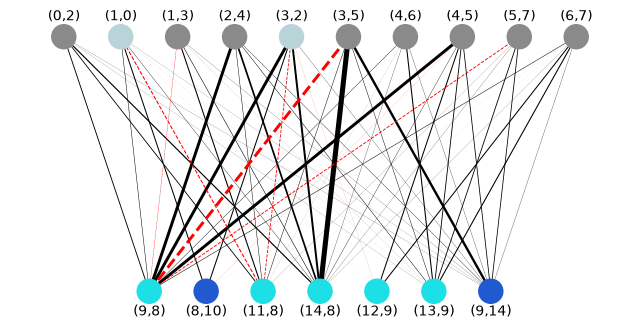

In [18]:
# s = best_partition[0]

idx_c = 0
for s in gbest_partition:

    nodec = [1 if s[i] > 0 else 0 for i in range(len(s))]
    # Partition
    # draw_sibigraph_nodec(Gb, nodec, cmap_name='coolwarm', figname=lab_G+lab_p+'-exact{}'.format(idx_c), figsize=figsize)
    # Switching
    # update the labels
    node_c = [nodec][0]

    # s = [1 if node_c[i] == 1 else -1 for i in range(len(node_c))]
    S = np.diag(s)
    W_s = S.dot(W.dot(S))
    B_s = W_s[:len(edges1), :][:, -len(edges2):]

    labels_p1s = []
    labels_p2s = []
    for i in range(len(edges1)):
        if node_c[i] == 1:
            labels_p1s.append(labels_p1[i])
        else:
            e = edges1[i]
            labels_p1s.append('({},{})'.format(e[1], e[0]))
    for j in range(len(edges2)):
        if node_c[j+len(edges1)] == 1:
            labels_p2s.append(labels_p2[j])
        else:
            e = edges2[j]
            labels_p2s.append('({},{})'.format(e[1]+G1.number_of_nodes(), e[0]+G1.number_of_nodes()))

    Gb_s = build_sibigraph(B_s, labels_p1s, labels_p2s)
    draw_sibigraph(Gb_s, figname=lab_G+'-switch'+lab_p+'-exact{}'.format(idx_c), figsize=figsize)
    draw_sibigraph_node2c(Gb_s, node_c, figname=lab_G+'-switch'+lab_p+'-exact{}'.format(idx_c), figsize=figsize)

    idx_c += 1

#### Linking centrality

In [19]:
# set the same range (This is post-processing after summarizing the values in the examples)
cmin = 0.02538
cmax = 1.111413
crange = [cmin, cmax]

In [20]:
# compute the linking centrality
cmap = 'plasma'
matrix = Lam_gli.copy()
# For G1: absolute row sum (assume one value per edge, e.g., left-aligned)
row_sums = np.abs(matrix).sum(axis=1)
# For G2: absolute column sum (one per edge)
col_sums = np.abs(matrix).sum(axis=0)


plot_networkx_colore(G1, G2, pos1, pos2, row_sums, col_sums, camera=camera, val_range=crange,
                     lab_name=lab_G+'-cent', cmap=cmap, xval=.85, cbar_len=0.6,
                     figsize=figsize_g, nlabel=False)

max, min abs value in 1st and 2nd edge vals: 1.111413 0.02538


### EG 2

In [21]:
# Circuit with squares + circuit with trees
# import random
lab_G = 'EG-2'

# Step 1: Create 3D grid graph G1
G1 = nx.grid_2d_graph(4, 2)

# Place nodes at z=0
for (i, j) in G1.nodes():
    G1.nodes[(i, j)]['pos'] = (i, j, 0)

# numeric the labels
labs1 = list(G1.nodes())
lab_num = list(range(len(labs1)))
G1 = nx.relabel_nodes(G1, dict(zip(G1.nodes(), lab_num)))

# Step 2: Create a small tree
pos = {0: (1,-1,0.5), 2: (0,-1,0.5), 3: (0,0,1),
      1: (2,0,-0.5), 4: (3,0,-0.5), 5: (3,-1,-1),
      6: (1.5, .5, -.5)}
edgelist = [(0,1), (0,2), (0,3), (1,4), (1,5),
            (0,6), (1,6)]

G2 = nx.Graph()
G2.add_nodes_from(pos.keys())
G2.add_edges_from(edgelist)
nx.set_node_attributes(G2, pos, name='pos')

graph_sets = [G1, G2]

In [22]:
# visualization
pos1 = extract_positions(graph_sets[0])
pos2 = extract_positions(graph_sets[1])

# ---- Create traces ----
trace_edges_G1 = edge_trace_3d(graph_sets[0], pos1, '#8a8a8a', 10)
trace_nodes_G1 = node_trace_3d(graph_sets[0], pos1, '#3f3f40', 8)

trace_edges_G2 = edge_trace_3d(graph_sets[1], pos2, '#2159d1', 10)
trace_nodes_G2 = node_trace_3d(graph_sets[1], pos2, '#3f3f40', 8)

# ---- Combine and plot ----
fig = go.Figure(data=[
    trace_edges_G1, trace_nodes_G1,
    trace_edges_G2, trace_nodes_G2
])

fig.update_layout(
    # title="3D Graph Visualization: G1_3D and G3",
    scene=dict(
        xaxis=dict(title='x'),
        yaxis=dict(title='y'),
        zaxis=dict(title='z'),
    ),
    showlegend=False,
    margin=dict(l=0, r=0, b=0, t=0),
    height=700
)
# fig.update_layout(scene_camera=camera)

fig.show()

In [23]:
camera = dict(
    eye=dict(x=-0.5, y=1.8, z=.5),
    center=dict(x=0, y=0, z=0),
    up=dict(x=0, y=0, z=.1)
) # for EG-1

fig.update_layout(scene_camera=camera)
fig.show()

In [24]:
figsize_g=(700, 500)
pio.write_image(fig, "{}-G.png".format(lab_G), width=figsize_g[0], height=figsize_g[1], scale=2) #, scale=2

In [25]:
plot_networkx_12label(G1, G2, pos1, pos2, camera=camera, lab_name=lab_G+'-G', figsize=figsize_g)

In [26]:
# GLI between edges directly
edges1 = list(graph_sets[0].edges())
edges2 = list(graph_sets[1].edges())

Lam_gli = np.zeros((len(edges1), len(edges2)))
for i in range(Lam_gli.shape[0]):
    e1 = edges1[i]
    e1_pos = [np.array(graph_sets[0].nodes[e1[0]]['pos']), np.array(graph_sets[0].nodes[e1[1]]['pos'])]
    for j in range(Lam_gli.shape[1]):
        e2 = edges2[j]
        # record the position
        e2_pos = [np.array(graph_sets[1].nodes[e2[0]]['pos']), np.array(graph_sets[1].nodes[e2[1]]['pos'])]
        # direct computation of Gauss linking integral
        gli_ij = Gauss_linking_integral(e1_pos, e2_pos)
        Lam_gli[i, j] = gli_ij

max abs value in Lam_gli: 0.384375922884024


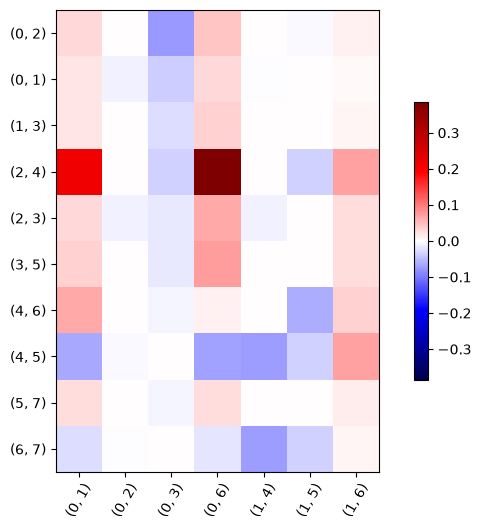

In [27]:
# Visualization
val_max = np.abs(Lam_gli).max()
print("max abs value in Lam_gli:", val_max)

plt.figure(figsize=(9, 6))
plt.imshow(Lam_gli, cmap='seismic', vmax=val_max, vmin=-val_max) #, aspect='auto'
# Set tick positions (match number of labels)
plt.xticks(ticks=np.arange(len(edges2)), labels=edges2, rotation=60)
plt.yticks(ticks=np.arange(len(edges1)), labels=edges1)

# Optional: show grid or colorbar
plt.grid(False)
plt.colorbar(shrink=0.6)
# plt.savefig("lad-Lam_gli.png", dpi=300, bbox_inches='tight')
plt.show()

#### Signed nature

In [28]:
labels_p1 = ['({},{})'.format(e[0], e[1]) for e in edges1]
labels_p2 = ['({},{})'.format(e[0]+G1.number_of_nodes(), e[1]+G1.number_of_nodes()) for e in edges2]

Gb = build_sibigraph(Lam_gli, labels_p1, labels_p2)

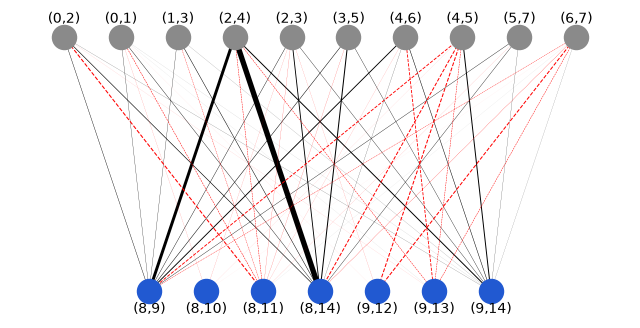

In [29]:
figsize = (8, 4)
draw_sibigraph(Gb, figname=lab_G, figsize=figsize, lab_diff=0.07)

In [30]:
# check the balance
W = np.block([[np.zeros((Lam_gli.shape[0], Lam_gli.shape[0])), Lam_gli], [Lam_gli.T, np.zeros((Lam_gli.shape[1], Lam_gli.shape[1]))]])

deg = np.sum(abs(W), axis=1)
# D_inv = np.diag(1./deg)
# P = D_inv.dot(W)
# eigvals = np.linalg.eigvals(P)

# symmetric version
D2_inv = np.diag(1./np.sqrt(deg))
P_sym = D2_inv.dot(W).dot(D2_inv)
eigvals = np.linalg.eigvals(P_sym)
print("Max eigenval of P:", np.max(eigvals))
# print("eigenvalues of P:", eigvals)

Max eigenval of P: (0.919168884594496+0j)


Min eigenvalues of L: 0.01771998014531036
Min eigenvalue(s) of L: [0.01771998]


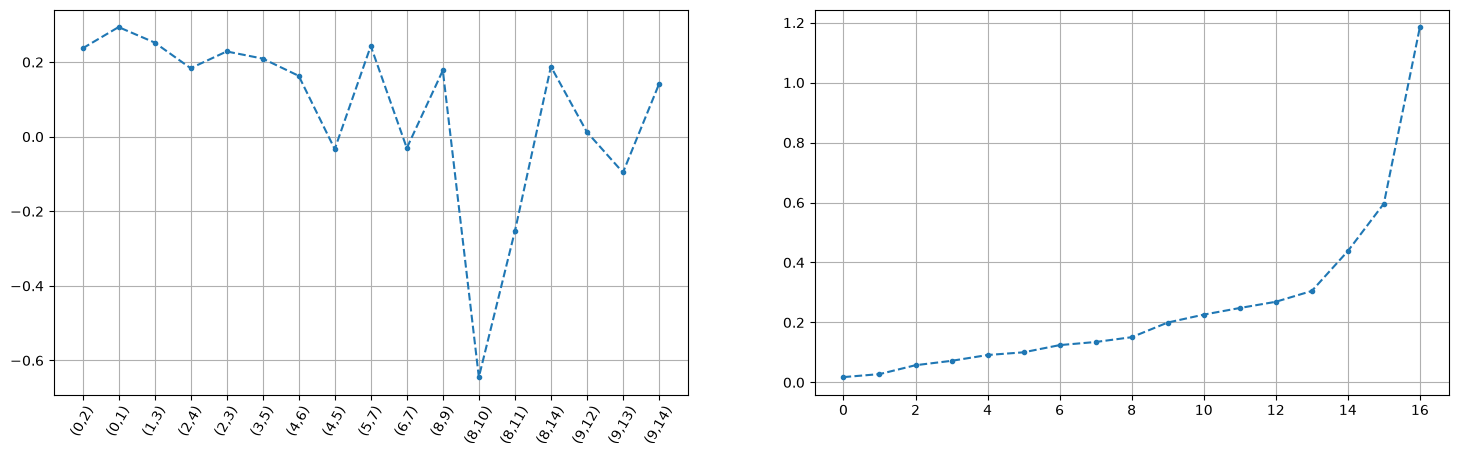

In [31]:
# check the eigenvectors
W = np.block([[np.zeros((Lam_gli.shape[0], Lam_gli.shape[0])), Lam_gli], [Lam_gli.T, np.zeros((Lam_gli.shape[1], Lam_gli.shape[1]))]])

deg = np.sum(abs(W), axis=1)
D = np.diag(deg)

L = D - W
eigvals, eigvecs = np.linalg.eigh(L)
print("Min eigenvalues of L:", min(eigvals))

# indices of the smallest value
tol = 1e-4
eval_min = min(eigvals)
idx = [i for i, val in enumerate(eigvals) if abs(val-eval_min) < tol]
print("Min eigenvalue(s) of L:", eigvals[idx])

plt.figure(figsize=(18, 5))
plt.subplot(121)
# choose the eigenvector(s)
for i in idx:
    plt.plot(eigvecs[:, i], marker='.', linestyle='dashed')
# xticks = edges1.copy()
# xticks.extend(edges2)
xticks = ['({},{})'.format(e[0], e[1]) for e in edges1]
xticks.extend(['({},{})'.format(e[0]+G1.number_of_nodes(), e[1]+G1.number_of_nodes()) for e in edges2])
plt.xticks(ticks=np.arange(len(xticks)), labels=xticks, rotation=60)
plt.grid(True)

plt.subplot(122)
plt.plot(eigvals, marker='.', linestyle='dashed')
plt.grid(True)
plt.show()

Min eigenvalues of L sym: 0.0808311154055039
Min eigenvalue(s) of L sym: [0.08083112]


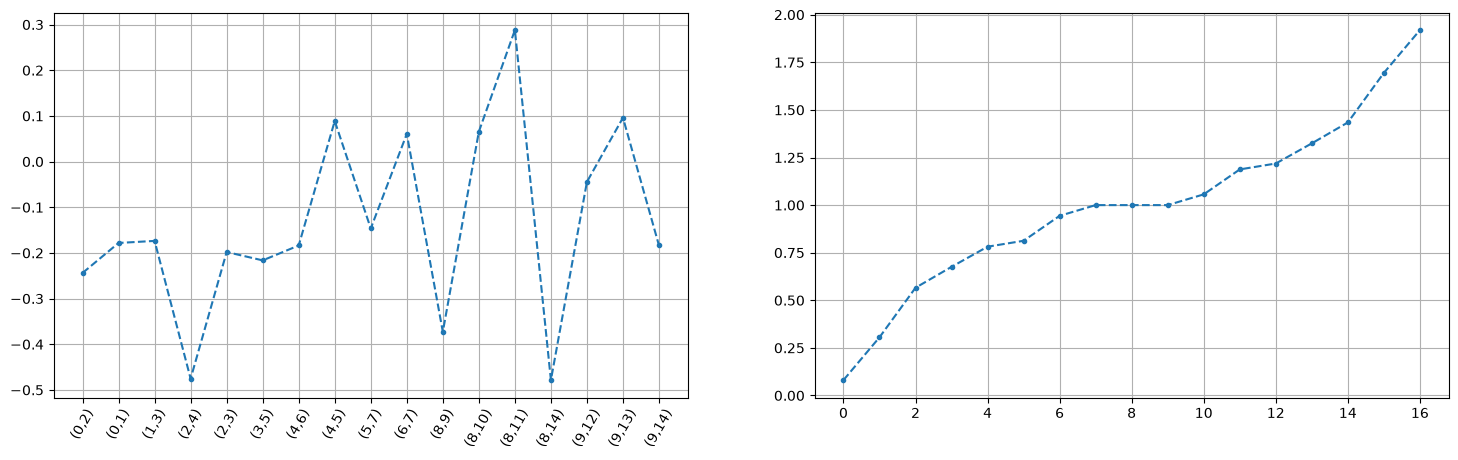

In [32]:
# check the eigenvectors - normalized Laplacian
W = np.block([[np.zeros((Lam_gli.shape[0], Lam_gli.shape[0])), Lam_gli], [Lam_gli.T, np.zeros((Lam_gli.shape[1], Lam_gli.shape[1]))]])

deg = np.sum(abs(W), axis=1)
D2_inv = np.diag(1./np.sqrt(deg))
L_sym = np.eye(W.shape[0]) - D2_inv.dot(W).dot(D2_inv)

eigvals, eigvecs = np.linalg.eigh(L_sym)
print("Min eigenvalues of L sym:", min(eigvals))

# indices of the smallest value
tol = 1e-4
eval_min = min(eigvals)
idx = [i for i, val in enumerate(eigvals) if abs(val-eval_min) < tol]
print("Min eigenvalue(s) of L sym:", eigvals[idx])

plt.figure(figsize=(18, 5))
plt.subplot(121)
# choose the eigenvector(s)
for i in idx:
    plt.plot(eigvecs[:, i], marker='.', linestyle='dashed')
# xticks = edges1.copy()
# xticks.extend(edges2)
xticks = ['({},{})'.format(e[0], e[1]) for e in edges1]
xticks.extend(['({},{})'.format(e[0]+G1.number_of_nodes(), e[1]+G1.number_of_nodes()) for e in edges2])
plt.xticks(ticks=np.arange(len(xticks)), labels=xticks, rotation=60)
plt.grid(True)

plt.subplot(122)
plt.plot(eigvals, marker='.', linestyle='dashed')
plt.grid(True)
plt.show()

Since all the values are clear from zero, we can use the vanilla format of the bi-clustering: separating the nodes into two clusters according to the sign of their corresponding elements in the eigenvector.

In [33]:
### Bi-Clustering ###
tol = 1e-4
nodec = []
idx_0s = []

for i,val in enumerate(eigvecs[:, idx[0]]):
    if val > tol:
        nodec.append(2)
    elif val < -tol:
        nodec.append(0)
    else:
        idx_0s.append(i)
        nodec.append(1)

if len(idx_0s) == 0:
    print("clear cut!")
    nodec = [1 if nodec[i] > 0 else 0 for i in range(len(nodec))]
else:
    print("# zeros in the eigenvector:", len(idx_0s))

clear cut!


In [34]:
# record the clustering result
s = np.array([1. if nodec[i] > 0 else -1. for i in range(len(nodec))]) # Default: all zeros in the same group as negatives
best_cost = s.T.dot(L).dot(s)
best_partition = [s]
size = len(idx_0s)
idx_0s = np.array(idx_0s)

print("Best cost:", best_cost)
print("# Best partition:", len(best_partition))

Best cost: 0.6628986683473311
# Best partition: 1


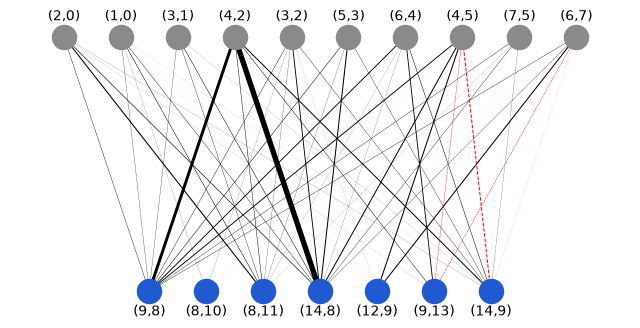

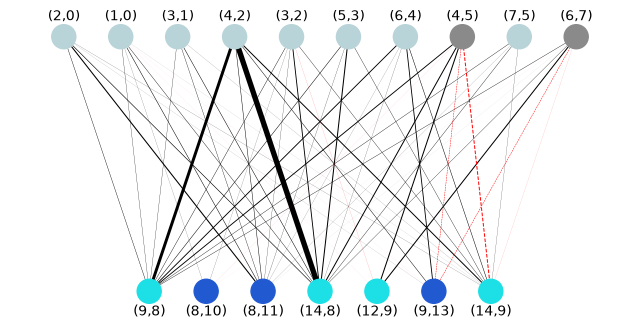

In [35]:
# Let's see the clustering result
lab_p = ''

idx_c = 0
for s in best_partition:

    nodec = [1 if s[i] > 0 else 0 for i in range(len(s))]
    # Partition
    # draw_sibigraph_nodec(Gb, nodec, cmap_name='coolwarm', figname=lab_G+lab_p+'-exact{}'.format(idx_c), figsize=figsize)
    # Switching
    # update the labels
    node_c = [nodec][0]

    # s = [1 if node_c[i] == 1 else -1 for i in range(len(node_c))]
    S = np.diag(s)
    W_s = S.dot(W.dot(S))
    B_s = W_s[:len(edges1), :][:, -len(edges2):]

    labels_p1s = []
    labels_p2s = []
    for i in range(len(edges1)):
        if node_c[i] == 1:
            labels_p1s.append(labels_p1[i])
        else:
            e = edges1[i]
            labels_p1s.append('({},{})'.format(e[1], e[0]))
    for j in range(len(edges2)):
        if node_c[j+len(edges1)] == 1:
            labels_p2s.append(labels_p2[j])
        else:
            e = edges2[j]
            labels_p2s.append('({},{})'.format(e[1]+G1.number_of_nodes(), e[0]+G1.number_of_nodes()))

    Gb_s = build_sibigraph(B_s, labels_p1s, labels_p2s)
    draw_sibigraph(Gb_s, figname=lab_G+'-switch'+lab_p+'-s{}'.format(idx_c), figsize=figsize)
    draw_sibigraph_node2c(Gb_s, node_c, figname=lab_G+'-switch'+lab_p+'-s{}'.format(idx_c), figsize=figsize)

    idx_c += 1

##### Check-ups

In [36]:
# check the exact solution -- only if small!!!
tol = 1e-4

gbest_cost = float(best_cost)
gbest_partition = []

size = L.shape[0]
s = np.ones(size)
for num in range(1, int((size+1.)/2. + 1)):
    # for every combination of the "num" number of nodes
    for idx_c in combinations(list(range(size)), num):
        s_now = s.copy()
        s_now[list(idx_c)] = -1
        cost = s_now.T.dot(L).dot(s_now)
        if cost < gbest_cost-tol:
            gbest_cost = cost
            gbest_partition = [s_now]
        elif abs(cost-gbest_cost) < tol:
            gbest_partition.append(s_now)

print("Best cost:", gbest_cost)
print("Best partition:", gbest_partition)

Best cost: 0.6628986683473311
Best partition: [array([ 1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1., -1.,  1., -1., -1.,
        1.,  1., -1.,  1.])]


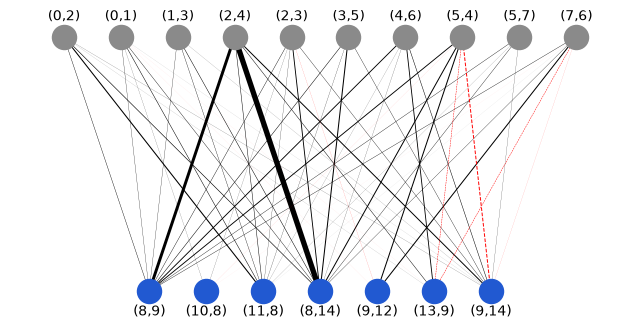

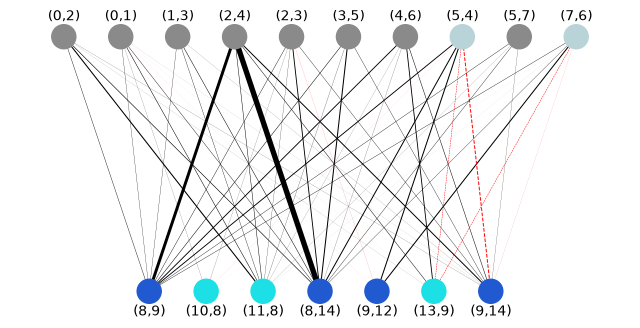

In [37]:
# s = best_partition[0]

idx_c = 0
for s in gbest_partition:

    nodec = [1 if s[i] > 0 else 0 for i in range(len(s))]
    # Partition
    # draw_sibigraph_nodec(Gb, nodec, cmap_name='coolwarm', figname=lab_G+lab_p+'-exact{}'.format(idx_c), figsize=figsize)
    # Switching
    # update the labels
    node_c = [nodec][0]

    # s = [1 if node_c[i] == 1 else -1 for i in range(len(node_c))]
    S = np.diag(s)
    W_s = S.dot(W.dot(S))
    B_s = W_s[:len(edges1), :][:, -len(edges2):]

    labels_p1s = []
    labels_p2s = []
    for i in range(len(edges1)):
        if node_c[i] == 1:
            labels_p1s.append(labels_p1[i])
        else:
            e = edges1[i]
            labels_p1s.append('({},{})'.format(e[1], e[0]))
    for j in range(len(edges2)):
        if node_c[j+len(edges1)] == 1:
            labels_p2s.append(labels_p2[j])
        else:
            e = edges2[j]
            labels_p2s.append('({},{})'.format(e[1]+G1.number_of_nodes(), e[0]+G1.number_of_nodes()))

    Gb_s = build_sibigraph(B_s, labels_p1s, labels_p2s)
    draw_sibigraph(Gb_s, figname=lab_G+'-switch'+lab_p+'-exact{}'.format(idx_c), figsize=figsize)
    draw_sibigraph_node2c(Gb_s, node_c, figname=lab_G+'-switch'+lab_p+'-exact{}'.format(idx_c), figsize=figsize)

    idx_c += 1

#### Linking centrality

In [38]:
# set the same range all
cmin = 0.02538
cmax = 1.111413
crange = [cmin, cmax]

In [39]:
# compute the linking centrality
cmap = 'plasma'
matrix = Lam_gli.copy()
# For G1: absolute row sum (assume one value per edge, e.g., left-aligned)
row_sums = np.abs(matrix).sum(axis=1)
# For G2: absolute column sum (one per edge)
col_sums = np.abs(matrix).sum(axis=0)


plot_networkx_colore(G1, G2, pos1, pos2, row_sums, col_sums, camera=camera, val_range=crange,
                     lab_name=lab_G+'-cent', cmap=cmap, xval=.85, cbar_len=0.6,
                     figsize=figsize_g, nlabel=False)

max, min abs value in 1st and 2nd edge vals: 1.111413 0.02538


### EG 3

In [40]:
# Circuit with squares + circuit with trees
# import random
lab_G = 'EG-3'

# Step 1: Create 3D grid graph G1
G1 = nx.grid_2d_graph(4, 2)

# Place nodes at z=0
for (i, j) in G1.nodes():
    G1.nodes[(i, j)]['pos'] = (i, j, 0)

# numeric the labels
labs1 = list(G1.nodes())
lab_num = list(range(len(labs1)))
G1 = nx.relabel_nodes(G1, dict(zip(G1.nodes(), lab_num)))

# Step 2: Create a small tree
pos = {0: (1,0,0.5), 2: (0,0,0.5), 3: (0,1,1),
      1: (2,1,-0.5), 4: (3,1,-0.5), 5: (3,0,-1),
      6: (1.5, -.5, 0)}
edgelist = [(0,1), (0,2), (0,3), (1,4), (1,5),
            (0,6), (1,6)]

G2 = nx.Graph()
G2.add_nodes_from(pos.keys())
G2.add_edges_from(edgelist)
nx.set_node_attributes(G2, pos, name='pos')

graph_sets = [G1, G2]

In [41]:
# visualization
pos1 = extract_positions(graph_sets[0])
pos2 = extract_positions(graph_sets[1])

# ---- Create traces ----
trace_edges_G1 = edge_trace_3d(graph_sets[0], pos1, '#8a8a8a', 10)
trace_nodes_G1 = node_trace_3d(graph_sets[0], pos1, '#3f3f40', 8)

trace_edges_G2 = edge_trace_3d(graph_sets[1], pos2, '#2159d1', 10)
trace_nodes_G2 = node_trace_3d(graph_sets[1], pos2, '#3f3f40', 8)

# ---- Combine and plot ----
fig = go.Figure(data=[
    trace_edges_G1, trace_nodes_G1,
    trace_edges_G2, trace_nodes_G2
])

fig.update_layout(
    # title="3D Graph Visualization: G1_3D and G3",
    scene=dict(
        xaxis=dict(title='x'),
        yaxis=dict(title='y'),
        zaxis=dict(title='z'),
    ),
    showlegend=False,
    margin=dict(l=0, r=0, b=0, t=0),
    height=700
)
# fig.update_layout(scene_camera=camera)

fig.show()

In [42]:
camera = dict(
    eye=dict(x=0., y=1.8, z=.6),
    center=dict(x=0, y=0, z=0),
    up=dict(x=0, y=0, z=.1)
) # this is for EG-3

fig.update_layout(scene_camera=camera)
fig.show()

In [43]:
figsize_g=(700, 500)
pio.write_image(fig, "{}-G.png".format(lab_G), width=figsize_g[0], height=figsize_g[1], scale=2) #, scale=2

In [44]:
plot_networkx_12label(G1, G2, pos1, pos2, camera=camera, lab_name=lab_G+'-G', figsize=figsize_g)

In [45]:
# GLI between edges directly
edges1 = list(graph_sets[0].edges())
edges2 = list(graph_sets[1].edges())

Lam_gli = np.zeros((len(edges1), len(edges2)))
for i in range(Lam_gli.shape[0]):
    e1 = edges1[i]
    e1_pos = [np.array(graph_sets[0].nodes[e1[0]]['pos']), np.array(graph_sets[0].nodes[e1[1]]['pos'])]
    for j in range(Lam_gli.shape[1]):
        e2 = edges2[j]
        # record the position
        e2_pos = [np.array(graph_sets[1].nodes[e2[0]]['pos']), np.array(graph_sets[1].nodes[e2[1]]['pos'])]
        # direct computation of Gauss linking integral
        gli_ij = Gauss_linking_integral(e1_pos, e2_pos)
        Lam_gli[i, j] = gli_ij

max abs value in Lam_gli: 0.3649072047774011


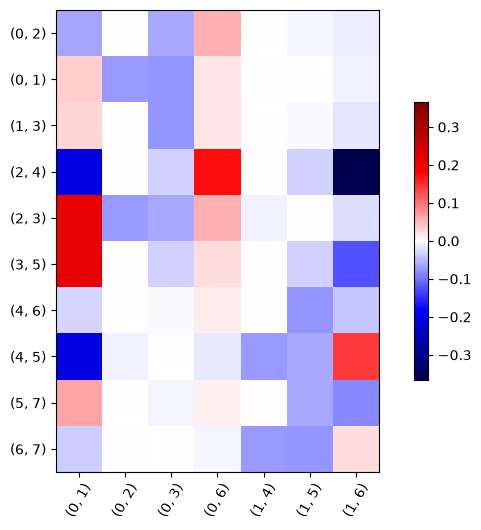

In [46]:
# Visualization
val_max = np.abs(Lam_gli).max()
print("max abs value in Lam_gli:", val_max)

plt.figure(figsize=(9, 6))
plt.imshow(Lam_gli, cmap='seismic', vmax=val_max, vmin=-val_max) #, aspect='auto'
# Set tick positions (match number of labels)
plt.xticks(ticks=np.arange(len(edges2)), labels=edges2, rotation=60)
plt.yticks(ticks=np.arange(len(edges1)), labels=edges1)

# Optional: show grid or colorbar
plt.grid(False)
plt.colorbar(shrink=0.6)
# plt.savefig("lad-Lam_gli.png", dpi=300, bbox_inches='tight')
plt.show()

#### Signed nature

In [47]:
labels_p1 = ['({},{})'.format(e[0], e[1]) for e in edges1]
labels_p2 = ['({},{})'.format(e[0]+G1.number_of_nodes(), e[1]+G1.number_of_nodes()) for e in edges2]

Gb = build_sibigraph(Lam_gli, labels_p1, labels_p2)

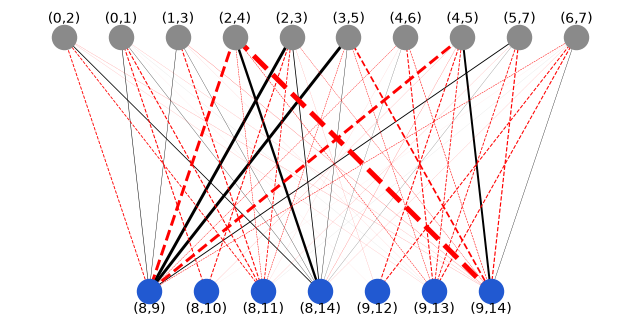

In [48]:
figsize = (8, 4)
draw_sibigraph(Gb, figname=lab_G, figsize=figsize, lab_diff=0.07)

In [49]:
# check the balance
W = np.block([[np.zeros((Lam_gli.shape[0], Lam_gli.shape[0])), Lam_gli], [Lam_gli.T, np.zeros((Lam_gli.shape[1], Lam_gli.shape[1]))]])

deg = np.sum(abs(W), axis=1)
# D_inv = np.diag(1./deg)
# P = D_inv.dot(W)
# eigvals = np.linalg.eigvals(P)

# symmetric version
D2_inv = np.diag(1./np.sqrt(deg))
P_sym = D2_inv.dot(W).dot(D2_inv)
eigvals = np.linalg.eigvals(P_sym)
print("Max eigenval of P:", np.max(eigvals))
# print("eigenvalues of P:", eigvals)

Max eigenval of P: 0.8037362261915793


Min eigenvalues of L: 0.05921845435688996
Min eigenvalue(s) of L: [0.05921845]


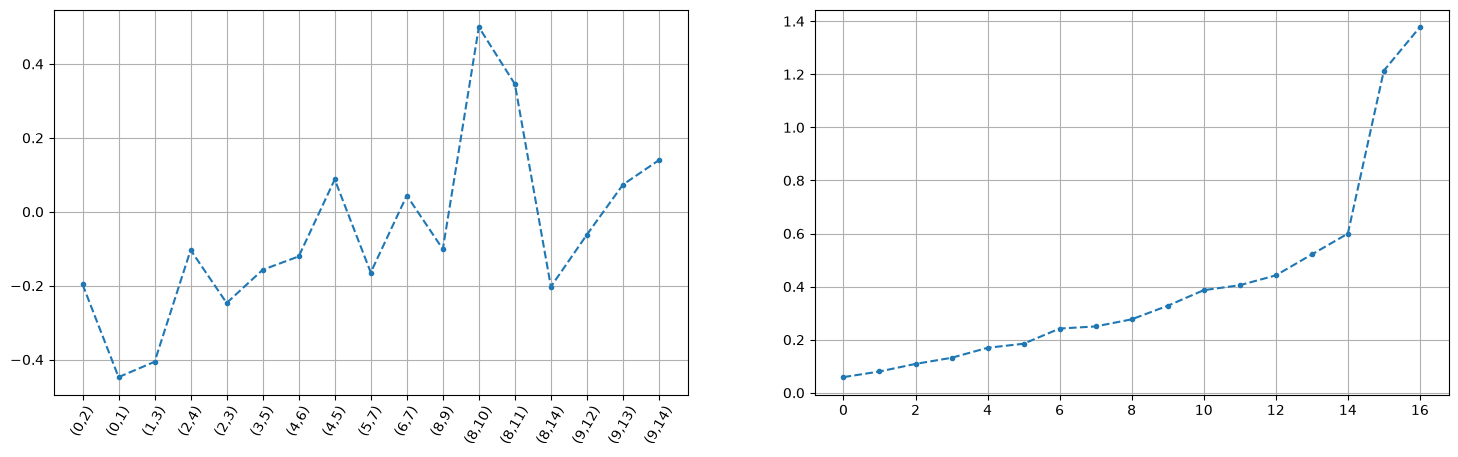

In [50]:
# check the eigenvectors
W = np.block([[np.zeros((Lam_gli.shape[0], Lam_gli.shape[0])), Lam_gli], [Lam_gli.T, np.zeros((Lam_gli.shape[1], Lam_gli.shape[1]))]])

deg = np.sum(abs(W), axis=1)
D = np.diag(deg)

L = D - W
eigvals, eigvecs = np.linalg.eigh(L)
print("Min eigenvalues of L:", min(eigvals))

# indices of the smallest value
tol = 1e-4
eval_min = min(eigvals)
idx = [i for i, val in enumerate(eigvals) if abs(val-eval_min) < tol]
print("Min eigenvalue(s) of L:", eigvals[idx])

plt.figure(figsize=(18, 5))
plt.subplot(121)
# choose the eigenvector(s)
for i in idx:
    plt.plot(eigvecs[:, i], marker='.', linestyle='dashed')
# xticks = edges1.copy()
# xticks.extend(edges2)
xticks = ['({},{})'.format(e[0], e[1]) for e in edges1]
xticks.extend(['({},{})'.format(e[0]+G1.number_of_nodes(), e[1]+G1.number_of_nodes()) for e in edges2])
plt.xticks(ticks=np.arange(len(xticks)), labels=xticks, rotation=60)
plt.grid(True)

plt.subplot(122)
plt.plot(eigvals, marker='.', linestyle='dashed')
plt.grid(True)
plt.show()

Min eigenvalues of L sym: 0.19626377380842017
Min eigenvalue(s) of L sym: [0.19626377]


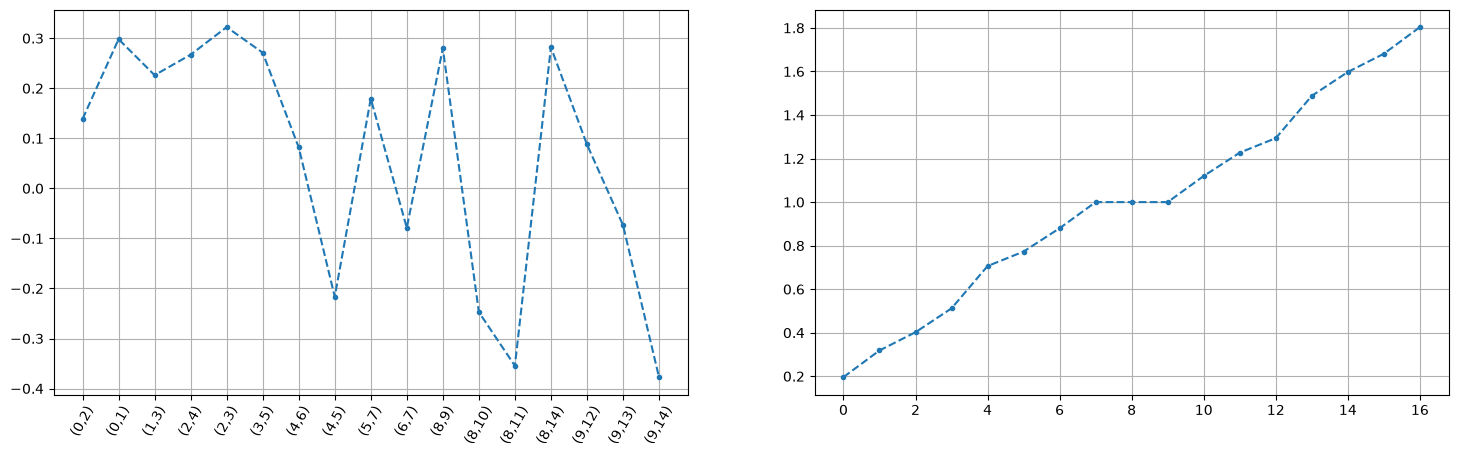

In [51]:
# check the eigenvectors - normalized Laplacian
W = np.block([[np.zeros((Lam_gli.shape[0], Lam_gli.shape[0])), Lam_gli], [Lam_gli.T, np.zeros((Lam_gli.shape[1], Lam_gli.shape[1]))]])

deg = np.sum(abs(W), axis=1)
D2_inv = np.diag(1./np.sqrt(deg))
L_sym = np.eye(W.shape[0]) - D2_inv.dot(W).dot(D2_inv)

eigvals, eigvecs = np.linalg.eigh(L_sym)
print("Min eigenvalues of L sym:", min(eigvals))

# indices of the smallest value
tol = 1e-4
eval_min = min(eigvals)
idx = [i for i, val in enumerate(eigvals) if abs(val-eval_min) < tol]
print("Min eigenvalue(s) of L sym:", eigvals[idx])

plt.figure(figsize=(18, 5))
plt.subplot(121)
# choose the eigenvector(s)
for i in idx:
    plt.plot(eigvecs[:, i], marker='.', linestyle='dashed')
# xticks = edges1.copy()
# xticks.extend(edges2)
xticks = ['({},{})'.format(e[0], e[1]) for e in edges1]
xticks.extend(['({},{})'.format(e[0]+G1.number_of_nodes(), e[1]+G1.number_of_nodes()) for e in edges2])
plt.xticks(ticks=np.arange(len(xticks)), labels=xticks, rotation=60)
plt.grid(True)

plt.subplot(122)
plt.plot(eigvals, marker='.', linestyle='dashed')
plt.grid(True)
plt.show()

Since all the values are clear from zero, we can use the vanilla format of the bi-clustering: separating the nodes into two clusters according to the sign of their corresponding elements in the eigenvector.

In [52]:
### Bi-Clustering ###
tol = 1e-2
nodec = []
idx_0s = []

for i,val in enumerate(eigvecs[:, idx[0]]):
    if val > tol:
        nodec.append(2)
    elif val < -tol:
        nodec.append(0)
    else:
        idx_0s.append(i)
        nodec.append(1)

if len(idx_0s) == 0:
    print("clear cut!")
    nodec = [1 if nodec[i] > 0 else 0 for i in range(len(nodec))]
else:
    print("# zeros in the eigenvector:", len(idx_0s))

clear cut!


In [53]:
# record the clustering result
s = np.array([1. if nodec[i] > 0 else -1. for i in range(len(nodec))]) # Default: all zeros in the same group as negatives
best_cost = s.T.dot(L).dot(s)
best_partition = [s]
size = len(idx_0s)
idx_0s = np.array(idx_0s)

print("Best cost:", best_cost)
print("# Best partition:", len(best_partition))

Best cost: 1.884096855620104
# Best partition: 1


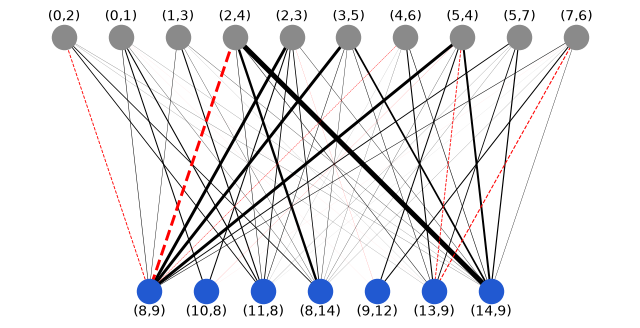

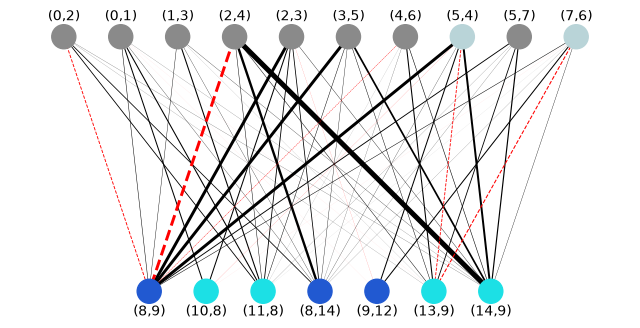

In [54]:
# Let's see the clustering result
lab_p = ''

idx_c = 0
for s in best_partition:

    nodec = [1 if s[i] > 0 else 0 for i in range(len(s))]
    # Partition
    # draw_sibigraph_nodec(Gb, nodec, cmap_name='coolwarm', figname=lab_G+lab_p+'-exact{}'.format(idx_c), figsize=figsize)
    # Switching
    # update the labels
    node_c = [nodec][0]

    # s = [1 if node_c[i] == 1 else -1 for i in range(len(node_c))]
    S = np.diag(s)
    W_s = S.dot(W.dot(S))
    B_s = W_s[:len(edges1), :][:, -len(edges2):]

    labels_p1s = []
    labels_p2s = []
    for i in range(len(edges1)):
        if node_c[i] == 1:
            labels_p1s.append(labels_p1[i])
        else:
            e = edges1[i]
            labels_p1s.append('({},{})'.format(e[1], e[0]))
    for j in range(len(edges2)):
        if node_c[j+len(edges1)] == 1:
            labels_p2s.append(labels_p2[j])
        else:
            e = edges2[j]
            labels_p2s.append('({},{})'.format(e[1]+G1.number_of_nodes(), e[0]+G1.number_of_nodes()))

    Gb_s = build_sibigraph(B_s, labels_p1s, labels_p2s)
    draw_sibigraph(Gb_s, figname=lab_G+'-switch'+lab_p+'-s{}'.format(idx_c), figsize=figsize)
    draw_sibigraph_node2c(Gb_s, node_c, figname=lab_G+'-switch'+lab_p+'-s{}'.format(idx_c), figsize=figsize)

    idx_c += 1

##### Check-ups

In [55]:
# check the exact solution -- only if small!!!
tol = 1e-4

gbest_cost = float(best_cost)
gbest_partition = []

size = L.shape[0]
s = np.ones(size)
for num in range(1, int((size+1.)/2. + 1)):
    # for every combination of the "num" number of nodes
    for idx_c in combinations(list(range(size)), num):
        s_now = s.copy()
        s_now[list(idx_c)] = -1
        cost = s_now.T.dot(L).dot(s_now)
        if cost < gbest_cost-tol:
            gbest_cost = cost
            gbest_partition = [s_now]
        elif abs(cost-gbest_cost) < tol:
            gbest_partition.append(s_now)

print("Best cost:", gbest_cost)
print("Best partition:", gbest_partition)

Best cost: 1.884096855620104
Best partition: [array([ 1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1., -1.,  1., -1., -1.,
        1.,  1., -1., -1.])]


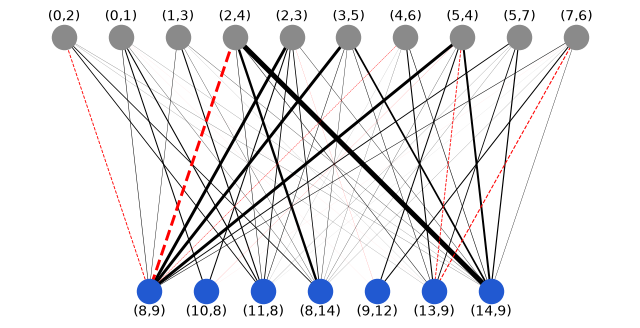

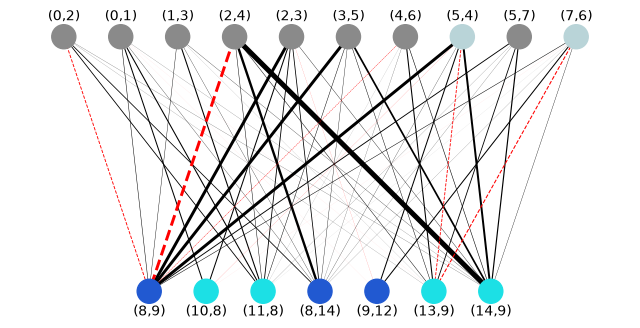

In [56]:
# s = best_partition[0]

idx_c = 0
for s in gbest_partition:

    nodec = [1 if s[i] > 0 else 0 for i in range(len(s))]
    # Partition
    # draw_sibigraph_nodec(Gb, nodec, cmap_name='coolwarm', figname=lab_G+lab_p+'-exact{}'.format(idx_c), figsize=figsize)
    # Switching
    # update the labels
    node_c = [nodec][0]

    # s = [1 if node_c[i] == 1 else -1 for i in range(len(node_c))]
    S = np.diag(s)
    W_s = S.dot(W.dot(S))
    B_s = W_s[:len(edges1), :][:, -len(edges2):]

    labels_p1s = []
    labels_p2s = []
    for i in range(len(edges1)):
        if node_c[i] == 1:
            labels_p1s.append(labels_p1[i])
        else:
            e = edges1[i]
            labels_p1s.append('({},{})'.format(e[1], e[0]))
    for j in range(len(edges2)):
        if node_c[j+len(edges1)] == 1:
            labels_p2s.append(labels_p2[j])
        else:
            e = edges2[j]
            labels_p2s.append('({},{})'.format(e[1]+G1.number_of_nodes(), e[0]+G1.number_of_nodes()))

    Gb_s = build_sibigraph(B_s, labels_p1s, labels_p2s)
    draw_sibigraph(Gb_s, figname=lab_G+'-switch'+lab_p+'-exact{}'.format(idx_c), figsize=figsize)
    draw_sibigraph_node2c(Gb_s, node_c, figname=lab_G+'-switch'+lab_p+'-exact{}'.format(idx_c), figsize=figsize)

    idx_c += 1

#### Linking centrality

In [57]:
# set the same range for all
cmin = 0.02538
cmax = 1.111413
crange = [cmin, cmax]

In [58]:
# compute the linking centrality
cmap = 'plasma'
matrix = Lam_gli.copy()
# For G1: absolute row sum (assume one value per edge, e.g., left-aligned)
row_sums = np.abs(matrix).sum(axis=1)
# For G2: absolute column sum (one per edge)
col_sums = np.abs(matrix).sum(axis=0)

plot_networkx_colore(G1, G2, pos1, pos2, row_sums, col_sums, camera=camera, val_range=crange,
                     lab_name=lab_G+'-cent', cmap=cmap, xval=.88, cbar_len=0.6,
                     figsize=figsize_g, nlabel=False)

max, min abs value in 1st and 2nd edge vals: 1.111413 0.02538
